# Grad-CAM Explainability

Notebook placeholder for explainability visualizations.

In [2]:
import numpy as np
import tensorflow as tf
import cv2
import matplotlib.pyplot as plt

from tensorflow.keras.models import load_model

In [3]:
model = load_model("../models/chest_xray_cnn_model.keras")

print("Model Loaded Successfully")

Model Loaded Successfully


In [16]:
image_path = r"D:\chest xray\chest_xray\test\PNEUMONIA\person1_virus_6.jpeg"

In [17]:
import os

test_path = r"D:\chest xray\chest_xray\test\PNEUMONIA"

print(os.listdir(test_path)[:10])

['person100_bacteria_475.jpeg', 'person100_bacteria_477.jpeg', 'person100_bacteria_478.jpeg', 'person100_bacteria_479.jpeg', 'person100_bacteria_480.jpeg', 'person100_bacteria_481.jpeg', 'person100_bacteria_482.jpeg', 'person101_bacteria_483.jpeg', 'person101_bacteria_484.jpeg', 'person101_bacteria_485.jpeg']


(640, 944, 3)


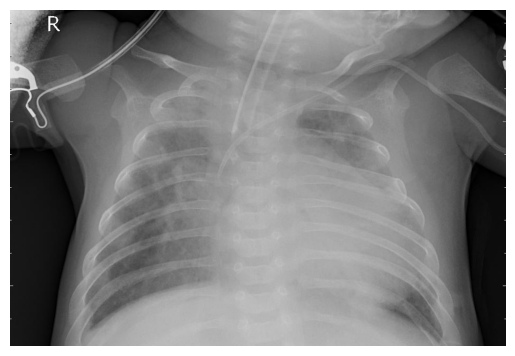

In [18]:
image = cv2.imread(image_path)

print(image.shape)

plt.imshow(cv2.cvtColor(image , cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

In [19]:
image = cv2.imread(image_path)

# store original image for visualization later
original_image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# convert to grayscale
gray_image = cv2.cvtColor(image,cv2.COLOR_BGR2GRAY)

#Resize
resized_image = cv2.resize(gray_image,(224,224))

# normalize 
normalized_image = resized_image/255.0

# add batch dimension and channel dimension
input_image = normalized_image.reshape(1,224,224,1)

print(input_image.shape)

(1, 224, 224, 1)


In [23]:
predictions = model.predict(input_image)

print("Prediction Probability:" , predictions[0][0])

if predictions[0][0] >0.5:
    print("Prediction : Pneumonia")
else:
    print("Prediction : Normal")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step
Prediction Probability: 0.9999714
Prediction : Pneumonia


In [26]:
for layer in model.layers:
    print(layer.name , layer.output.shape)

conv2d (None, 222, 222, 32)
max_pooling2d (None, 111, 111, 32)
conv2d_1 (None, 109, 109, 64)
max_pooling2d_1 (None, 54, 54, 64)
conv2d_2 (None, 52, 52, 128)
max_pooling2d_2 (None, 26, 26, 128)
flatten (None, 86528)
dense (None, 128)
dropout (None, 128)
dense_1 (None, 1)


In [31]:
grad_model = tf.keras.models.Model(
    inputs=model.inputs,
    outputs=[
        model.get_layer(last_conv_layer_name).output,
        model.outputs[0]
    ]
)

In [32]:
conv_outputs, predictions = grad_model(input_image)

print(conv_outputs.shape)
print(predictions.numpy())

c:\Users\suhani gupta\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\models\functional.py:259: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['input_layer']
Received: inputs=Tensor(shape=(1, 224, 224, 1))
  warnings.warn(msg)


(1, 52, 52, 128)
[[0.9999714]]


In [36]:
with tf.GradientTape() as tape:
    conv_outputs, predictions = grad_model(input_image)
    tape.watch(conv_outputs)
    loss = predictions[:, 0]

gradients = tape.gradient(loss, conv_outputs)

print(gradients is None)
print(gradients.shape)

True


AttributeError: 'NoneType' object has no attribute 'shape'

In [37]:
print(type(input_image))
print(input_image.shape)
print(type(conv_outputs))
print(conv_outputs.shape)
print(predictions)

<class 'numpy.ndarray'>
(1, 224, 224, 1)
<class 'tensorflow.python.framework.ops.EagerTensor'>
(1, 52, 52, 128)
tf.Tensor([[0.9999714]], shape=(1, 1), dtype=float32)


In [38]:
input_tensor = tf.convert_to_tensor(input_image, dtype=tf.float32)

with tf.GradientTape() as tape:
    conv_outputs, predictions = grad_model(input_tensor)
    loss = predictions[:, 0]

gradients = tape.gradient(loss, conv_outputs)

print(gradients is None)
print(gradients.shape)

True


AttributeError: 'NoneType' object has no attribute 'shape'

In [39]:
print(tf.__version__)
print(tf.keras.__version__)

2.21.0
3.15.0


In [40]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,505,541 (127.81 MB)

 Trainable params: 11,168,513 (42.60 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 22,337,028 (85.21 MB)

In [41]:
last_conv_layer_name = ...

grad_model = ...

In [42]:
last_conv_layer_name = "conv2d_2"

last_conv_layer = model.get_layer(last_conv_layer_name)

conv_model = tf.keras.models.Model(
    inputs=model.inputs,
    outputs=last_conv_layer.output
)

classifier_input = tf.keras.Input(shape=last_conv_layer.output.shape[1:])

x = classifier_input
start = False

for layer in model.layers:
    if layer.name == last_conv_layer_name:
        start = True
        continue
    if start:
        x = layer(x)

classifier_model = tf.keras.models.Model(classifier_input, x)

In [43]:
input_tensor = tf.convert_to_tensor(input_image, dtype=tf.float32)

with tf.GradientTape() as tape:
    conv_outputs = conv_model(input_tensor)
    tape.watch(conv_outputs)
    predictions = classifier_model(conv_outputs)
    loss = predictions[:, 0]

gradients = tape.gradient(loss, conv_outputs)

print(gradients is None)
print(gradients.shape)
print(predictions.numpy())

False
(1, 52, 52, 128)
[[0.9999714]]
